# Attention and Transformers

**Applied ML in Production · Bonus 4 of 4**

---

Bonus 3 ended with a measurement: a recurrent network's gradient twenty steps back
was a ten-thousandth of its size at the final step. Every piece of information has
to squeeze through one hidden state, one step at a time, and the distant past
fades.

**Attention** removes the bottleneck. Instead of carrying a summary forward, every
position looks directly at every other position and takes what it needs. No
recurrence, no fading, and — because nothing has to happen in order — the whole
sequence processes in parallel.

That idea is the transformer, and it is the architecture behind every large
language model you have used. We build it from scratch: attention in ten lines,
then multiple heads, then positions, then a full block, then we train one.

## How to work through this

Type the code. Section 1's ten lines are the entire idea; everything after is
packaging.

The whole notebook runs in about a minute on a laptop CPU.

## Learning objectives

After this session you will be able to:

- Explain attention as query, key and value, and compute it by hand.
- Implement scaled dot-product attention and say why the scaling is there.
- Describe multi-head attention and what the heads are for.
- Explain why a transformer needs **positional encoding**, and demonstrate it.
- Assemble a transformer block: attention, feed-forward, residuals, layer norm.
- Train a small transformer and read its attention weights.
- Describe causal masking, and how GPT-style generation works.
- Place BERT, GPT and fine-tuning in context — and say when to train nothing at all.

In [1]:
%matplotlib inline

import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": False})
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__)

torch 2.13.0


---

## 1. Attention: query, key, value

The mechanism is a soft dictionary lookup.

Each position produces three vectors:

- a **query** — what am I looking for?
- a **key** — what do I contain?
- a **value** — what do I pass on if selected?

Compare one query against every key, turn those similarities into weights with a
softmax, and return the weighted average of the values.

$$ \text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V $$

Here it is with numbers small enough to check by hand.

In [2]:
def attention(queries, keys, values):
    """Scaled dot-product attention. Returns the output and the weights."""
    d_k = queries.shape[-1]
    scores = queries @ keys.transpose(-2, -1) / math.sqrt(d_k)
    weights = scores.softmax(dim=-1)
    return weights @ values, weights


# Three positions, each with a 2-dimensional key and a 2-dimensional value.
keys = torch.tensor([[1.0, 0.0],      # position 0 contains "direction A"
                     [0.0, 1.0],      # position 1 contains "direction B"
                     [1.0, 1.0]])     # position 2 contains a bit of both
values = torch.tensor([[10.0, 0.0],
                       [0.0, 10.0],
                       [5.0, 5.0]])

query = torch.tensor([[4.0, -2.0]])   # strongly looking for "direction A", away from B

output, weights = attention(query, keys, values)
print("attention weights:", weights.numpy().round(3))
print("output:           ", output.numpy().round(2))

attention weights: [[0.795 0.011 0.193]]
output:            [[8.92 1.08]]


Position 0 takes about 80% of the weight, so the output is close to position 0's
value of `[10, 0]`. Change the query and the output changes, with no parameters
involved at all — attention is a *lookup rule*, and the learning happens in how
the queries, keys and values are produced.

In [3]:
for description, query in [("looking for A", torch.tensor([[4.0, -2.0]])),
                           ("looking for B", torch.tensor([[-2.0, 4.0]])),
                           ("looking for both", torch.tensor([[2.0, 2.0]])),
                           ("no preference", torch.tensor([[0.0, 0.0]]))]:
    _, weights = attention(query, keys, values)
    print(f"{description:<18} weights {weights.numpy().round(3)}")

looking for A      weights [[0.795 0.011 0.193]]
looking for B      weights [[0.011 0.795 0.193]]
looking for both   weights [[0.164 0.164 0.673]]
no preference      weights [[0.333 0.333 0.333]]


Two rows are worth pausing on. "Looking for both" spreads weight onto position 2,
which contains a bit of each direction. And a zero query gives equal weight to
everything — attention degenerates into a plain average. Sharpness comes from the scores being different,
which is why the **scaling by √dₖ** exists. Without it, dot products in high
dimensions grow large, the softmax saturates, one position takes all the weight,
and the gradients vanish.

In [4]:
for dimension in [4, 64, 512]:
    torch.manual_seed(0)
    q = torch.randn(1, dimension)
    k = torch.randn(6, dimension)
    unscaled = (q @ k.T).softmax(dim=-1)
    scaled = (q @ k.T / math.sqrt(dimension)).softmax(dim=-1)
    print(f"d_k={dimension:>3}  max weight without scaling {unscaled.max():.3f}   "
          f"with scaling {scaled.max():.3f}")

d_k=  4  max weight without scaling 0.570   with scaling 0.370
d_k= 64  max weight without scaling 0.864   with scaling 0.349
d_k=512  max weight without scaling 1.000   with scaling 0.502


---

## 2. Self-attention

In **self**-attention the queries, keys and values all come from the same
sequence, through three learned linear projections. Every position gets to ask
every other position — including itself — what it contains.

In [5]:
class SelfAttention(nn.Module):
    def __init__(self, dimension):
        super().__init__()
        self.to_query = nn.Linear(dimension, dimension)
        self.to_key = nn.Linear(dimension, dimension)
        self.to_value = nn.Linear(dimension, dimension)

    def forward(self, x):                      # x: (batch, time, dimension)
        output, weights = attention(self.to_query(x), self.to_key(x), self.to_value(x))
        return output, weights


layer = SelfAttention(dimension=16)
sequence = torch.randn(1, 5, 16)               # one sequence, five positions
output, weights = layer(sequence)

print("input ", tuple(sequence.shape))
print("output", tuple(output.shape), "— same shape; every position rewritten using the others")
print("\nattention weight matrix (row = who is asking, column = who is being read):")
print(weights[0].detach().numpy().round(2))

input  (1, 5, 16)
output (1, 5, 16) — same shape; every position rewritten using the others

attention weight matrix (row = who is asking, column = who is being read):
[[0.13 0.15 0.24 0.19 0.29]
 [0.3  0.22 0.22 0.14 0.13]
 [0.16 0.24 0.24 0.18 0.18]
 [0.32 0.3  0.13 0.17 0.09]
 [0.15 0.13 0.18 0.29 0.25]]


Each row sums to 1: every position distributes its attention across the sequence.
Untrained, the pattern is close to uniform — the structure appears with training,
as we will see in section 6.

Two properties worth stating explicitly.

**Every position reaches every other in one step.** There is no distance penalty:
position 1 and position 500 are equally far apart, which is exactly what
recurrence could not manage.

**The cost is quadratic.** The weight matrix is length × length, so doubling the
sequence length quadruples the computation. This is the transformer's central
limitation and the reason "context window" is a headline number for language
models.

In [6]:
for length in [128, 1_024, 8_192]:
    print(f"sequence length {length:>6}: attention matrix has {length ** 2:>14,} entries")

sequence length    128: attention matrix has         16,384 entries
sequence length   1024: attention matrix has      1,048,576 entries
sequence length   8192: attention matrix has     67,108,864 entries


---

## 3. Multi-head attention

One attention operation computes one kind of relationship. Language needs several
at once — grammatical agreement, coreference, topic. **Multi-head attention** runs
several attentions in parallel on slices of the vector, then concatenates them.

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, dimension, heads):
        super().__init__()
        self.heads = heads
        self.head_dimension = dimension // heads
        self.to_query = nn.Linear(dimension, dimension)
        self.to_key = nn.Linear(dimension, dimension)
        self.to_value = nn.Linear(dimension, dimension)
        self.project = nn.Linear(dimension, dimension)
        self.last_weights = None               # kept so we can look at them later

    def split(self, x):
        batch, time, _ = x.shape
        return x.view(batch, time, self.heads, self.head_dimension).transpose(1, 2)

    def forward(self, x):
        batch, time, dimension = x.shape
        output, weights = attention(self.split(self.to_query(x)),
                                    self.split(self.to_key(x)),
                                    self.split(self.to_value(x)))
        self.last_weights = weights.detach()   # (batch, heads, time, time)
        output = output.transpose(1, 2).reshape(batch, time, dimension)
        return self.project(output)


multi_head = MultiHeadAttention(dimension=48, heads=4)
result = multi_head(torch.randn(2, 10, 48))

print("output       ", tuple(result.shape))
print("weights      ", tuple(multi_head.last_weights.shape), "= (batch, heads, time, time)")
print("\nfour heads, each working in 48 / 4 = 12 dimensions")

output        (2, 10, 48)
weights       (2, 4, 10, 10) = (batch, heads, time, time)

four heads, each working in 48 / 4 = 12 dimensions


---

## 4. Positions: the thing attention forgets

Attention is a weighted average, and averages do not care about order. Shuffle the
sequence and self-attention produces the same set of outputs, just reordered — it
is **permutation-equivariant**.

Prove it before fixing it.

In [8]:
torch.manual_seed(0)
layer = SelfAttention(dimension=8)
sequence = torch.randn(1, 4, 8)

original, _ = layer(sequence)
shuffled, _ = layer(sequence[:, [2, 0, 3, 1]])       # same tokens, different order

print("output for position that moved 0 -> 1:")
print("  original:", original[0, 2].detach().numpy().round(3)[:4], "...")
print("  shuffled:", shuffled[0, 0].detach().numpy().round(3)[:4], "...")
print("\nidentical:", torch.allclose(original[0, 2], shuffled[0, 0], atol=1e-6))
print("\nAttention alone cannot tell 'dog bites man' from 'man bites dog'.")

output for position that moved 0 -> 1:
  original: [ 0.511  0.242 -0.149  0.502] ...
  shuffled: [ 0.511  0.242 -0.149  0.502] ...

identical: True

Attention alone cannot tell 'dog bites man' from 'man bites dog'.


The fix is to add position information to the token representations before
attention sees them. Two common choices:

**Learned positional embeddings** — an embedding table indexed by position,
trained like any other parameter. Simple, and what we use below.

**Sinusoidal encodings** — fixed sine and cosine waves of different frequencies,
from the original transformer paper. No parameters, and they extrapolate to
lengths never seen in training.

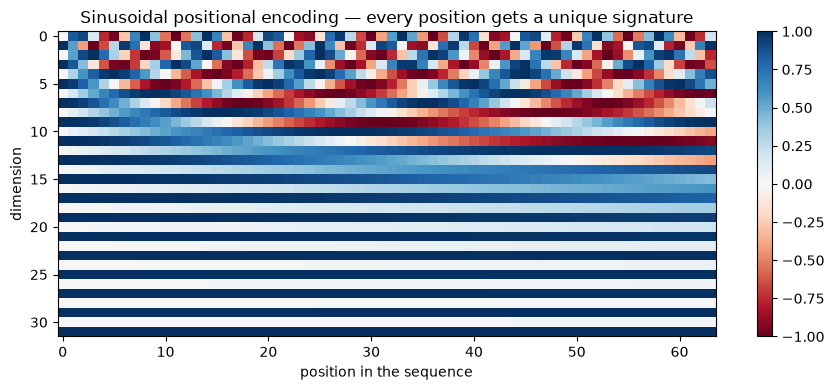

In [9]:
def sinusoidal_encoding(length, dimension):
    position = torch.arange(length).unsqueeze(1)
    step = torch.exp(torch.arange(0, dimension, 2) * (-math.log(10_000.0) / dimension))
    encoding = torch.zeros(length, dimension)
    encoding[:, 0::2] = torch.sin(position * step)
    encoding[:, 1::2] = torch.cos(position * step)
    return encoding


encoding = sinusoidal_encoding(64, 32)

plt.imshow(encoding.T, aspect="auto", cmap="RdBu")
plt.xlabel("position in the sequence")
plt.ylabel("dimension")
plt.title("Sinusoidal positional encoding — every position gets a unique signature")
plt.colorbar()
plt.tight_layout()
plt.show()

Each column is one position's signature. Nearby positions have similar patterns,
distant ones do not — so the network can learn to use "how far apart" as a feature.

---

## 5. The transformer block

One block is attention plus a small feed-forward network, each wrapped in a
**residual connection** and a **layer normalisation**.

| Component | Job |
|-----------|-----|
| Multi-head attention | Move information between positions |
| Feed-forward network | Process each position independently, in a wider space |
| Residual connection | `x + sublayer(x)` — keeps a clean gradient path through depth |
| Layer normalisation | Stabilises training by normalising each position's vector |

Attention mixes *across* positions; the feed-forward layer thinks *within* each
one. Stack a few blocks and you have a transformer.

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, dimension, heads, feedforward):
        super().__init__()
        self.attention = MultiHeadAttention(dimension, heads)
        self.norm1 = nn.LayerNorm(dimension)
        self.norm2 = nn.LayerNorm(dimension)
        self.feedforward = nn.Sequential(
            nn.Linear(dimension, feedforward), nn.ReLU(), nn.Linear(feedforward, dimension),
        )

    def forward(self, x):
        x = self.norm1(x + self.attention(x))        # attend, then add and normalise
        return self.norm2(x + self.feedforward(x))   # think, then add and normalise


block = TransformerBlock(dimension=48, heads=4, feedforward=96)
print(f"one block: {sum(p.numel() for p in block.parameters()):,} parameters")
print("output shape:", tuple(block(torch.randn(2, 10, 48)).shape), "— unchanged, so blocks stack")

one block: 18,960 parameters
output shape: (2, 10, 48) — unchanged, so blocks stack


---

## 6. Training one: associative recall

A task where attention should win outright. Each sequence is a list of
**key–value pairs**, then a query token, then one of the keys. The model must
output the value that was paired with that key.

A recurrent network has to memorise every pair in its hidden state and then find
the right one. Attention just looks it up.

In [11]:
N_PAIRS = 5
KEY_TOKENS = list(range(2, 9))          # tokens usable as keys
VALUE_TOKENS = list(range(9, 17))       # tokens usable as values
QUERY_TOKEN = 0
VOCABULARY = 17
LENGTH = N_PAIRS * 2 + 2


def make_sequences(n, seed=0):
    generator = torch.Generator().manual_seed(seed)
    inputs, targets = [], []

    for _ in range(n):
        keys = torch.randperm(len(KEY_TOKENS), generator=generator)[:N_PAIRS]
        values = torch.randint(0, len(VALUE_TOKENS), (N_PAIRS,), generator=generator)

        sequence = []
        for key, value in zip(keys, values):
            sequence += [KEY_TOKENS[key], VALUE_TOKENS[value]]

        asked = torch.randint(0, N_PAIRS, (1,), generator=generator).item()
        sequence += [QUERY_TOKEN, KEY_TOKENS[keys[asked]]]

        inputs.append(sequence)
        targets.append(VALUE_TOKENS[values[asked]])

    return torch.tensor(inputs), torch.tensor(targets)


x_train, y_train = make_sequences(8_000, seed=0)
x_test, y_test = make_sequences(1_000, seed=1)

print("one sequence:", x_train[0].tolist())
print("             ", " ".join(f"{'key' if i % 2 == 0 else 'val':>3}" for i in range(N_PAIRS * 2)),
      " query  ask")
print("answer:", y_train[0].item())
print(f"\nguessing would score {1 / len(VALUE_TOKENS):.3f}")

one sequence: [6, 12, 2, 16, 7, 10, 5, 12, 4, 14, 0, 2]
              key val key val key val key val key val  query  ask
answer: 16

guessing would score 0.125


In [12]:
class TinyTransformer(nn.Module):
    def __init__(self, vocabulary, length, dimension=48, heads=4, layers=2, feedforward=96):
        super().__init__()
        self.token_embedding = nn.Embedding(vocabulary, dimension)
        self.position_embedding = nn.Embedding(length, dimension)
        self.blocks = nn.ModuleList(
            [TransformerBlock(dimension, heads, feedforward) for _ in range(layers)])
        self.head = nn.Linear(dimension, vocabulary)

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device)
        h = self.token_embedding(x) + self.position_embedding(positions)[None]
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])          # predict from the final position


class GRUBaseline(nn.Module):
    def __init__(self, vocabulary, dimension=48, hidden=96):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary, dimension)
        self.recurrent = nn.GRU(dimension, hidden, batch_first=True)
        self.head = nn.Linear(hidden, vocabulary)

    def forward(self, x):
        output, _ = self.recurrent(self.embedding(x))
        return self.head(output[:, -1])


def train(model, epochs=15):
    optimiser = torch.optim.Adam(model.parameters(), lr=3e-3)
    loss_function = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(x_train, y_train), batch_size=128, shuffle=True)

    started = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in loader:
            optimiser.zero_grad()
            loss_function(model(batch_x), batch_y).backward()
            optimiser.step()

    model.eval()
    with torch.no_grad():
        accuracy = (model(x_test).argmax(dim=1) == y_test).float().mean().item()
    return accuracy, time.perf_counter() - started


torch.manual_seed(0)
gru = GRUBaseline(VOCABULARY)
gru_accuracy, gru_seconds = train(gru)
print(f"GRU         accuracy {gru_accuracy:.3f}   "
      f"({sum(p.numel() for p in gru.parameters()):,} parameters, {gru_seconds:.0f}s)")

torch.manual_seed(0)
transformer = TinyTransformer(VOCABULARY, LENGTH)
transformer_accuracy, transformer_seconds = train(transformer)
print(f"Transformer accuracy {transformer_accuracy:.3f}   "
      f"({sum(p.numel() for p in transformer.parameters()):,} parameters, {transformer_seconds:.0f}s)")

GRU         accuracy 0.354   (44,513 parameters, 3s)


Transformer accuracy 1.000   (40,145 parameters, 7s)


**Transformer 1.000, GRU 0.354**, at the same parameter budget, against a guessing
baseline of 0.125.

The GRU is not badly built — it is being asked to hold five arbitrary pairs in a
fixed-size state and retrieve one on demand. The transformer never has to
remember: the pairs are still sitting in the sequence, and attention fetches the
one it needs.

Content-based lookup over the whole input is what this architecture is *for*.

### Reading the attention weights

Because we kept `last_weights`, we can ask what the trained model actually looked at.

In [13]:
with torch.no_grad():
    prediction = transformer(x_test[:1])

sequence = x_test[0].tolist()
key_positions = {sequence[i]: i for i in range(0, N_PAIRS * 2, 2)}
asked_key = sequence[-1]
answer_position = key_positions[asked_key] + 1

print("sequence:      ", sequence)
print("positions:     ", list(range(LENGTH)))
print(f"\nthe query asks for key {asked_key}, which sits at position {key_positions[asked_key]}")
print(f"so the answer, value {y_test[0].item()}, is at position {answer_position}")
print(f"the model predicted {prediction.argmax(dim=1).item()}\n")

final_block_weights = transformer.blocks[-1].attention.last_weights[0]    # (heads, time, time)
for head in range(final_block_weights.shape[0]):
    top = final_block_weights[head, -1].topk(2)
    print(f"  head {head}: attends to positions {top.indices.tolist()} "
          f"with weights {[round(v, 2) for v in top.values.tolist()]}")

sequence:       [2, 12, 8, 14, 3, 16, 5, 9, 7, 9, 0, 7]
positions:      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

the query asks for key 7, which sits at position 8
so the answer, value 9, is at position 9
the model predicted 9

  head 0: attends to positions [9, 0] with weights [1.0, 0.0]
  head 1: attends to positions [9, 5] with weights [0.95, 0.01]
  head 2: attends to positions [9, 8] with weights [0.92, 0.04]
  head 3: attends to positions [9, 6] with weights [1.0, 0.0]


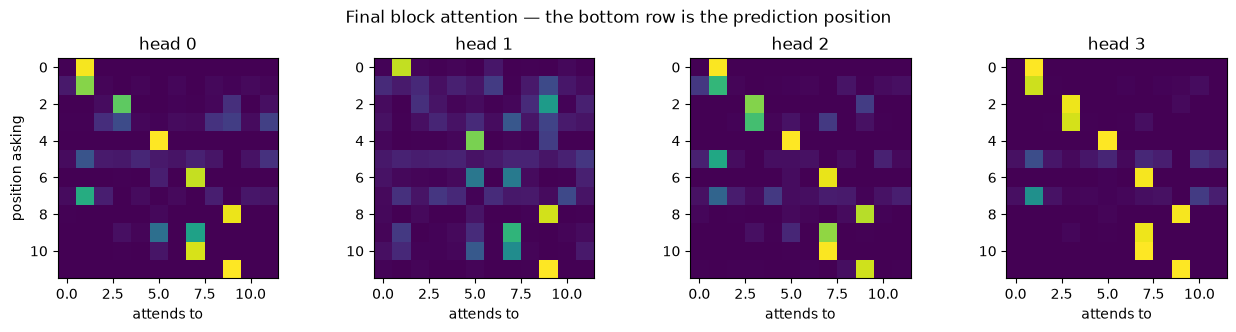

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for head, ax in enumerate(axes):
    ax.imshow(final_block_weights[head], cmap="viridis")
    ax.set_title(f"head {head}")
    ax.set_xlabel("attends to")
    if head == 0:
        ax.set_ylabel("position asking")
plt.suptitle("Final block attention — the bottom row is the prediction position")
plt.tight_layout()
plt.show()

Every head in the final block puts almost all of its weight on the position
holding the answer. The model learned the algorithm we would have written by
hand: *find the key that matches the query, then read the token next to it.*

This is what people mean when they say transformers are more interpretable than
recurrent networks. The attention map is not a full explanation — the weights
show *where* it looked, not *why* the answer is right — but it is far more than a
hidden state vector ever offered.

---

## 7. Masking, and how GPT writes

Our model is an **encoder**: every position sees every other, in both directions.
That is right for classification, and wrong for generation — a model predicting
the next word must not be allowed to look at it.

The fix is a **causal mask**: set the scores for future positions to −∞ before the
softmax, so their weight becomes zero.

In [15]:
def causal_attention(queries, keys, values):
    d_k = queries.shape[-1]
    scores = queries @ keys.transpose(-2, -1) / math.sqrt(d_k)

    length = scores.shape[-1]
    future = torch.triu(torch.ones(length, length, dtype=torch.bool), diagonal=1)
    scores = scores.masked_fill(future, float("-inf"))      # cannot see ahead

    weights = scores.softmax(dim=-1)
    return weights @ values, weights


_, weights = causal_attention(torch.randn(1, 5, 8), torch.randn(1, 5, 8), torch.randn(1, 5, 8))
print("causal attention weights (row = position, column = what it may read):")
print(weights[0].detach().numpy().round(2))

causal attention weights (row = position, column = what it may read):
[[1.   0.   0.   0.   0.  ]
 [0.39 0.61 0.   0.   0.  ]
 [0.93 0.02 0.05 0.   0.  ]
 [0.15 0.28 0.28 0.28 0.  ]
 [0.27 0.31 0.08 0.07 0.27]]


Lower triangular: position 0 sees only itself, position 4 sees everything up to
itself. That single change turns the encoder into a **decoder**, and a decoder
trained to predict the next token *is* a language model.

Generation is then a loop: predict the next token, append it, predict again. The
whole of GPT-style text generation is that loop around this masked block.

| Family | Masking | Trained to | Used for |
|--------|---------|-----------|----------|
| **Encoder** (BERT) | none — sees both directions | fill in masked tokens | classification, embeddings, search |
| **Decoder** (GPT) | causal | predict the next token | generation, chat, code |
| **Encoder–decoder** (T5, original transformer) | both | map one sequence to another | translation, summarisation |

---

## 8. From this notebook to the models you use

Our transformer has about 40,000 parameters, was trained for 15 seconds on 8,000
synthetic sequences, and does exactly one task.

A production language model differs in degree, not in kind:

| | This notebook | A large language model |
|---|---|---|
| Parameters | ~40 thousand | billions |
| Layers | 2 | dozens to over a hundred |
| Context length | 12 tokens | thousands to millions |
| Training data | 8,000 synthetic sequences | trillions of tokens of text |
| Training cost | 15 seconds, one CPU core | millions of dollars, thousands of GPUs |
| Tokens | integers we invented | subword pieces from a learned tokeniser |

The block you wrote in section 5 is, structurally, the block they use.

### What this means for your practice

**You will almost never train one.** The economics are decisive. The practical
skills are choosing a pretrained model, adapting it, and evaluating it.

**Adaptation, in increasing order of effort**: prompt it; retrieve relevant
context and put it in the prompt (RAG); fine-tune a small adapter (LoRA);
fine-tune fully. Most production systems stop at the second.

**Everything from sessions 1 to 10 still applies.** A language model in a product
is still a model that needs a decision it changes, a baseline to beat, a metric
tied to cost, error analysis by slice, a serving contract, and monitoring for
drift. The architecture changed; the engineering did not.

That is the last word of this module: the interesting part of applied machine
learning was never the architecture.

---

## Your turn

**1. Attention by hand.** Using the `keys` and `values` from section 1, find a
query that splits attention roughly 50/50 between positions 0 and 1. Verify it.

**2. Remove the scaling.** Delete `/ math.sqrt(d_k)` from `attention` and retrain
the transformer in section 6. What happens, and does it get worse as you increase
the dimension?

**3. Remove the positions.** Drop `position_embedding` from `TinyTransformer` and
retrain. Which part of the task becomes impossible, and why does accuracy not fall
all the way to 0.125?

**4. Harder recall.** Raise `N_PAIRS` to 10 and retrain both models. Does the
transformer hold? Does the GRU degrade further?

**5. One head or four.** Train with `heads=1` and with `heads=8` at the same total
dimension. Does this task need multiple heads, and what does that suggest about
when they matter?

**6. Build a character model.** Take any plain text file, tokenise it by
character, add the causal mask from section 7, and train the same block to predict
the next character. Generate 200 characters. It will be nonsense at first — how
much text does it take before it invents plausible words?

---

## If you remember nothing else

**Attention is a soft lookup.** Queries against keys, softmax, weighted average of
values. Ten lines.

**Self-attention gives every position direct access to every other.** No fading,
no distance penalty — and quadratic cost, which is why context windows are finite.

**The scaling by √dₖ keeps the softmax from saturating.**

**Attention alone is order-blind.** Positional encoding is what lets a transformer
tell "dog bites man" from "man bites dog".

**A block is attention + feed-forward, each with a residual and a layer norm.**
Stack them; that is the architecture.

**Attention is inspectable.** Our model put all its weight on the position holding
the answer — the algorithm, visible.

**Masking turns an encoder into a generator.** Hide the future, predict the next
token, loop.

**You will use these models, not train them.** And everything this module taught
about framing, metrics, error analysis, serving and monitoring applies unchanged.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Query, key, value** | What a position is looking for, what it contains, what it passes on |
| **Scaled dot-product attention** | softmax(QKᵀ/√dₖ)V |
| **Self-attention** | Q, K and V all derived from the same sequence |
| **Multi-head attention** | Several attentions in parallel over slices of the vector |
| **Positional encoding** | Position information added to token representations |
| **Residual connection** | `x + sublayer(x)`, keeping gradients flowing through depth |
| **Layer normalisation** | Normalising each position's vector to stabilise training |
| **Causal mask** | Blocking attention to future positions |
| **Encoder / decoder** | Bidirectional (BERT-style) / causal (GPT-style) stacks |
| **Context window** | The maximum sequence length a model can attend over |
| **Token** | The unit a model reads — usually a subword piece |
| **Pretraining / fine-tuning** | Learning general structure / adapting to your task |
| **LoRA** | Fine-tuning a small number of added parameters instead of all of them |

## Further reading

- Vaswani et al., *Attention Is All You Need* (2017) — the paper; eight pages,
  and now readable because you have implemented it.
- Jay Alammar, *The Illustrated Transformer* — the diagrams to pair with this code.
- Andrej Karpathy, *Let's build GPT: from scratch, in code, spelled out* — the
  natural next step after exercise 6.
- Hugging Face, *Transformers course* — how to use pretrained models properly,
  which is the skill you will actually need.

---

That is the bonus series: dense networks, convolutions, recurrence, attention.
Four architectures, one training loop, and the same discipline as the ten sessions
before them.